#Projeto de Análise de dados e Machine Learning - Predição de X coisa

**Responsáveis: Guilherme Torres do Ó e Rikelme Sousa de Carvalho**

**Dataset:** [Campeonato Brasileiro de futebol](https://www.kaggle.com/datasets/adaoduque/campeonato-brasileiro-de-futebol) (Kaggle)

**Objetivo:** construir um modelo de classificação capaz de prever se ...

Este notebook segue a estrutura pedida na entrega do Dojo:
1. Análise exploratória de dados
2. Limpeza e engenharia de atributos
3. Identificação das melhores variáveis
4. Divisão treino/teste
5. Aplicação de algoritmos de ML
6. Métricas de avaliação
7. Hyperparameter tuning

> Escolhemos o dataset Campeonato Brasileiro de futebol entre os sugeridos porque ele combina variáveis numéricas e categóricas, tem dados faltantes reais (bom exercício de tratamento) e permite criar novas features (como título extraído do nome).

## 1. Carregamento do dataset e importações

Usamos o arquivo `campeonato-brasileiro-full.csv` do dataset Campeonato Brasileiro de futebol, que contém os jogos do campeonato brasileiro de 2003 a 2025. É este arquivo que usamos para treinar e validar o modelo.

Conexão com o drive:

In [1]:
from google.colab import drive
drive.mount('/content/drive/')

Mounted at /content/drive/


Importação das bibliotecas:

In [7]:
# Bibliotecas de manipulação de dados
import pandas as pd
import numpy as np

# Bibliotecas de visualização
import matplotlib.pyplot as plt
import seaborn as sns

Importação do dataset:

In [3]:
df = pd.read_csv('/content/drive/MyDrive/Hype USP/Dojo_treinoparaprojeto/campeonato-brasileiro-full.csv')

Visualização das colunas do dataset:

In [ ]:
df

,ID,rodata,data,hora,mandante,visitante,formacao_mandante,formacao_visitante,tecnico_mandante,tecnico_visitante,vencedor,arena,mandante_Placar,visitante_Placar,mandante_Estado,visitante_Estado,arrecadacao
0,1,1,29/03/2003,16:00,Guarani,Vasco,NaN,NaN,NaN,NaN,Guarani,Brinco de Ouro,4,2,SP,RJ,NaN
1,2,1,29/03/2003,16:00,Athletico-PR,Gremio,NaN,NaN,NaN,NaN,Athletico-PR,Arena da Baixada,2,0,PR,RS,NaN
2,3,1,30/03/2003,16:00,Flamengo,Coritiba,NaN,NaN,NaN,NaN,-,Maracanã,1,1,RJ,PR,NaN
3,4,1,30/03/2003,16:00,Goias,Paysandu,NaN,NaN,NaN,NaN,-,Serra Dourada,2,2,GO,PA,NaN
4,5,1,30/03/2003,16:00,Internacional,Ponte Preta,NaN,NaN,NaN,NaN,-,Beira Rio,1,1,RS,SP,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9160,9160,38,07/12/2025,16:04,Santos,Cruzeiro,4-2-3-1,4-2-3-1,J. Vojvoda,T. Tite,Santos,"Estádio Urbano Caldeira, Santos",3,0,SP,MG,743978.75
9161,9161,38,07/12/2025,16:04,Sport,Gremio,5-4-1,4-2-3-1,C. de Lucena,L. Castro,Gremio,"Adelmar da Costa Carvalho, Recife",0,4,PE,RS,88755.00
9162,9163,38,07/12/2025,16:04,Botafogo-RJ,Fortaleza,4-2-3-1,4-4-2,Davide Ancelotti,Martin Palermo,Botafogo-RJ,"Estádio Nilton Santos, Rio de Janeiro",4,2,RJ,CE,905640.00
9163,9164,38,07/12/2025,16:04,Atletico-MG,Vasco,4-2-3-1,4-2-3-1,J. Sampaoli,F. Diniz,Atletico-MG,"Arena MRV, Belo Horizonte",5,0,MG,RJ,897255.52


Mostrar informações importantes(quantidade de linhas totais e quantidade de colunas do dataset):

In [ ]:
df.shape

(9165, 17)

Tipos das variáveis do dataset, quantidade nula/não nula de cada uma delas:

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9165 entries, 0 to 9164
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID                  9165 non-null   int64  
 1   rodata              9165 non-null   int64  
 2   data                9165 non-null   object 
 3   hora                9165 non-null   object 
 4   mandante            9165 non-null   object 
 5   visitante           9165 non-null   object 
 6   formacao_mandante   4190 non-null   object 
 7   formacao_visitante  4190 non-null   object 
 8   tecnico_mandante    4555 non-null   object 
 9   tecnico_visitante   4555 non-null   object 
 10  vencedor            9165 non-null   object 
 11  arena               9165 non-null   object 
 12  mandante_Placar     9165 non-null   int64  
 13  visitante_Placar    9165 non-null   int64  
 14  mandante_Estado     9165 non-null   object 
 15  visitante_Estado    9165 non-null   object 
 16  arreca

In [ ]:
# Ainda entendendo os tipos das colunas
df.dtypes

,0
ID,int64
rodata,int64
data,object
hora,object
mandante,object
visitante,object
formacao_mandante,object
formacao_visitante,object
tecnico_mandante,object
tecnico_visitante,object


Estatísticas descritivas das variáveis numéricas:

In [ ]:
df.describe()

,ID,rodata,mandante_Placar,visitante_Placar,arrecadacao
count,9165.000000,9165.000000,9165.000000,9165.000000,3.800000e+02
mean,4583.000000,20.080742,1.535188,1.026077,1.363330e+06
std,2645.851942,11.407037,1.226254,1.025470,1.158877e+06
min,1.000000,1.000000,0.000000,0.000000,6.187500e+04
25%,2292.000000,10.000000,1.000000,0.000000,4.731792e+05
50%,4583.000000,20.000000,1.000000,1.000000,9.962582e+05
75%,6874.000000,30.000000,2.000000,2.000000,1.916168e+06
max,9165.000000,46.000000,8.000000,7.000000,5.983920e+06


 Estatísticas descritivas das variáveis categóricas:

In [4]:
df.describe(include=["object"])

,data,hora,mandante,visitante,formacao_mandante,formacao_visitante,tecnico_mandante,tecnico_visitante,vencedor,arena,mandante_Estado,visitante_Estado
count,9165,9165,9165,9165,4190,4190,4555,4555,9165,9165,9165,9165
unique,2162,194,46,46,22,21,268,274,47,191,15,15
top,06/07/2008,16:00,Fluminense,Flamengo,4-2-3-1,4-2-3-1,L. Venker de Menezes,L. Venker de Menezes,-,Maracanã,SP,SP
freq,15,1963,447,448,2414,2266,141,144,2421,669,2287,2287


**Dicionário de variáveis (resumo):**

| Coluna | Descrição |
|---|---|
| ID / rodata / data / hora | Identificadores, exigem tratamento especial antes de virarem features úteis |
| mandante / visitante | Representam se o time jogou em casa ou fora de casa |
| formacao_mandante / formacao_visitante | Formação em que o time foi escalado para o jogo |
| tecnico_mandante / tecnico_visitante | Nome do técnico do time na partida em questão |
| vencedor | Time ganhador da partida. (-) significa empate |
| arena | Arena onde foi realizado o jogo |
| mandante_Placar / visitante_Placar | Quantidade de gols alcançada por cada time |
| mandante_Estado / visitante_Estado | Estado de origem de cada time |
| arrecadacao | Quantidade de dinheiro arrecadada pelo time mandante no jogo |


## 2. Análise de valores faltantes

Antes de qualquer modelagem, é essencial entender onde há dados faltantes, pois isso influencia diretamente as decisões de limpeza.

In [5]:
missing = df.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)
pd.DataFrame({"faltantes": missing, "% do total": missing_pct})[missing > 0]

,faltantes,% do total
arrecadacao,8785,95.85
formacao_mandante,4975,54.28
formacao_visitante,4975,54.28
tecnico_visitante,4610,50.30
tecnico_mandante,4610,50.30


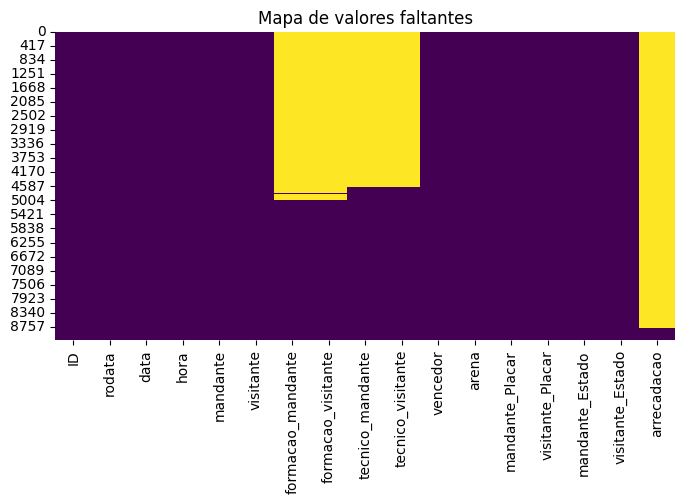

In [8]:
plt.figure(figsize=(8, 4))
sns.heatmap(df.isnull(), cbar=False, cmap="viridis")
plt.title("Mapa de valores faltantes")
plt.show()

**Observações:** TENHO QUE REVISAR ESSA PARTE ADICIONANDO "AS PROVAS" ACIMA
- `arrecadacao` tem ~96% de valores faltantes — posteriormente descobrimos que todos os valores que estão no dataset correspondem a temporada 2025. Ou seja, temos a arrecadação de cada jogo do Brasileirão 2025, apenas.
- `formacao_mandante / formacao_visitante` tem ~54% de faltantes. Na temporada 2025 esses dados estão completos.
- `tecnico_mandante / tecnico_visitante` tem ~50% valores faltantes.

Quantas colunas vazias tem o Rio de Janeiro:

In [ ]:
df_rio = df.loc[df['mandante_Estado'] =='RJ']
df_rio.isna().sum()

,0
ID,0
rodata,0
data,0
hora,0
mandante,0
visitante,0
formacao_mandante,892
formacao_visitante,892
tecnico_mandante,834
tecnico_visitante,834


Quantas colunas vazias tem SP:

In [ ]:
df_sp = df.loc[df['mandante_Estado'] == 'SP']
df_sp.isna().sum()

,0
ID,0
rodata,0
data,0
hora,0
mandante,0
visitante,0
formacao_mandante,1277
formacao_visitante,1277
tecnico_mandante,1205
tecnico_visitante,1205


Limpando todas as linhas nulas do dataset. **Observação:** descobri que as linhas não nulas correspondem a temporada 2025!


In [9]:
df_free = df.dropna()
df_free

,ID,rodata,data,hora,mandante,visitante,formacao_mandante,formacao_visitante,tecnico_mandante,tecnico_visitante,vencedor,arena,mandante_Placar,visitante_Placar,mandante_Estado,visitante_Estado,arrecadacao
8785,8786,1,29/03/2025,18:30,Juventude,Vitoria,4-2-3-1,4-2-3-1,M. Barbieri,J. Ventura,Juventude,"Alfredo Jaconi, Caxias do Sul",2,0,RS,BA,220000.00
8786,8787,1,29/03/2025,18:30,Fortaleza,Fluminense,3-4-3,4-3-3,T. Carpini,L. Luis Zubeldia,Fortaleza,"Arena Castelão, Fortaleza",2,0,CE,RJ,267643.00
8787,8790,1,29/03/2025,18:31,Cruzeiro,Mirassol,4-2-2-2,4-2-3-1,T. Tite,R. Guanaes,Cruzeiro,"Mineirão, Belo Horizonte",2,1,MG,SP,2089452.00
8788,8788,1,29/03/2025,18:32,Gremio,Atletico-MG,4-2-3-1,4-4-2,L. Castro,J. Sampaoli,Gremio,"Arena do Grêmio, Porto Alegre",2,1,RS,MG,1175509.00
8789,8789,1,29/03/2025,18:32,Sao Paulo,Sport,3-4-1-2,4-3-1-2,H. Crespo,C. de Lucena,-,"MorumBIS, São Paulo",0,0,SP,PE,2144747.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9160,9160,38,07/12/2025,16:04,Santos,Cruzeiro,4-2-3-1,4-2-3-1,J. Vojvoda,T. Tite,Santos,"Estádio Urbano Caldeira, Santos",3,0,SP,MG,743978.75
9161,9161,38,07/12/2025,16:04,Sport,Gremio,5-4-1,4-2-3-1,C. de Lucena,L. Castro,Gremio,"Adelmar da Costa Carvalho, Recife",0,4,PE,RS,88755.00
9162,9163,38,07/12/2025,16:04,Botafogo-RJ,Fortaleza,4-2-3-1,4-4-2,Davide Ancelotti,Martin Palermo,Botafogo-RJ,"Estádio Nilton Santos, Rio de Janeiro",4,2,RJ,CE,905640.00
9163,9164,38,07/12/2025,16:04,Atletico-MG,Vasco,4-2-3-1,4-2-3-1,J. Sampaoli,F. Diniz,Atletico-MG,"Arena MRV, Belo Horizonte",5,0,MG,RJ,897255.52


## 3. Análise Exploratória de Dados


### 3.1 Distribuição da variável alvo(TEMOS QUE DECIDIR QUAL É A VARIÁVEL ALVO PARA O NOSSIO MODELO)

### 3.2 Testes de curiosidade sobre os times que os responsáveis torcem

Ver jogos do palmeiras (criamos um data frame que mostra só os jogos do Palmeiras):

In [ ]:
df_pal = df.loc[(df['mandante'] == 'Palmeiras') | (df['visitante'] == 'Palmeiras')]
df_pal

,ID,rodata,data,hora,mandante,visitante,formacao_mandante,formacao_visitante,tecnico_mandante,tecnico_visitante,vencedor,arena,mandante_Placar,visitante_Placar,mandante_Estado,visitante_Estado,arrecadacao
556,557,1,21/04/2004,18:00,Palmeiras,Atletico-MG,NaN,NaN,NaN,NaN,-,Parque Antártica,0,0,SP,MG,NaN
567,568,2,25/04/2004,16:00,Internacional,Palmeiras,NaN,NaN,NaN,NaN,Internacional,Beira Rio,1,0,RS,SP,NaN
586,587,3,29/04/2004,20:30,Palmeiras,Vitoria,NaN,NaN,NaN,NaN,-,Parque Antártica,2,2,SP,BA,NaN
594,596,4,02/05/2004,16:00,Corinthians,Palmeiras,NaN,NaN,NaN,NaN,Palmeiras,Morumbi,0,4,SP,SP,NaN
604,606,5,08/05/2004,18:00,Palmeiras,Ponte Preta,NaN,NaN,NaN,NaN,Palmeiras,Parque Antártica,3,0,SP,SP,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9120,9117,37,19/11/2025,19:30,Palmeiras,Vitoria,4-2-3-1,3-4-2-1,A. Ferreira,J. Ventura,-,"Allianz Parque, São Paulo",0,0,SP,BA,2632317.00
9126,9137,35,22/11/2025,21:30,Palmeiras,Fluminense,4-4-2,4-2-3-1,A. Ferreira,L. Luis Zubeldia,-,"Allianz Parque, São Paulo",0,0,SP,RJ,2986721.80
9135,9147,36,25/11/2025,21:30,Gremio,Palmeiras,4-2-3-1,4-2-3-1,L. Castro,A. Ferreira,Gremio,"Arena do Grêmio, Porto Alegre",3,2,RS,SP,1314249.00
9148,9135,34,03/12/2025,21:30,Atletico-MG,Palmeiras,3-4-2-1,4-2-3-1,J. Sampaoli,A. Ferreira,Palmeiras,"Arena MRV, Belo Horizonte",0,3,MG,SP,535000.17


Quantos jogos o Palmeiras teve nesse período?

In [ ]:
df_pal.shape

(810, 17)

Quantas vezes o palmeiras ganhou nesse período?

In [ ]:
df_palGanhador = df_pal['vencedor'] == 'Palmeiras'
(df_palGanhador == True).sum()

np.int64(436)

### 3.3 Relações de arrecadação

Buscamos estabelecer uma relação entre o Estado do time mandante e a arrecadação entre os 4 Estados brasileiros mais tradicionais no futebol nacional

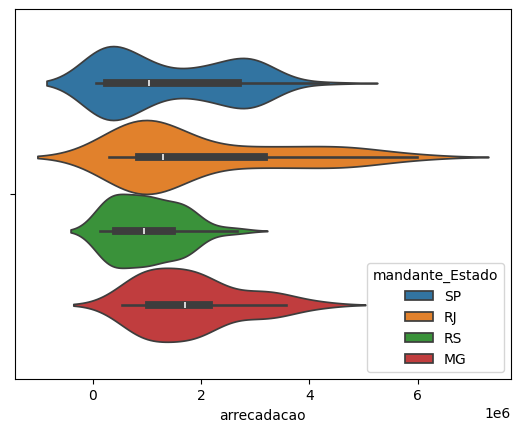

In [13]:
estados = ['RJ', 'SP', 'MG', 'RS']
df_filtered = df[df['mandante_Estado'].isin(estados)]
g = sns.violinplot(data = df_filtered, x = 'arrecadacao', hue='mandante_Estado')

Outro grafico, dessa vez mostrando arrecadação total por cada Estado

<Axes: xlabel='mandante_Estado', ylabel='arrecadacao'>

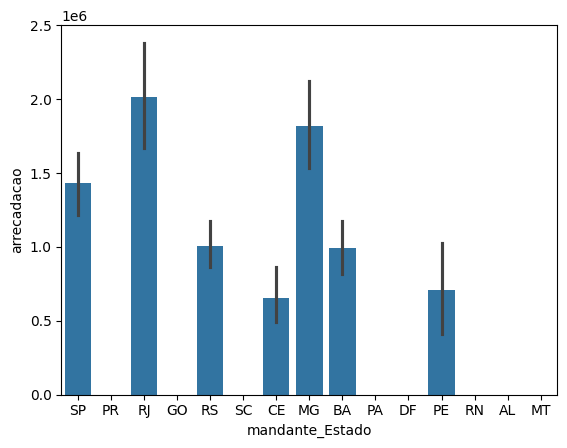

In [14]:
gb = sns.barplot(data = df, x = 'mandante_Estado', y = 'arrecadacao')
gb

Qual time de SP arrecadou mais dinheiro:

In [ ]:
df_sp.groupby('mandante')['arrecadacao'].sum().sort_values(ascending = False)

,arrecadacao
mandante,
Corinthians,54079722.40
Palmeiras,47680681.00
Sao Paulo,28598317.50
Santos,21513965.04
Mirassol,7427960.00
Bragantino,3494345.00
Guarani,0.00
Barueri,0.00
Gremio Prudente,0.00


Qual time do rio arrecadou mais dinheiro:

In [ ]:
df_rio.groupby('mandante')['arrecadacao'].sum().sort_values(ascending = False)

,arrecadacao
mandante,
Flamengo,81773984.0
Vasco,30996515.5
Fluminense,24651439.5
Botafogo-RJ,15519520.0


Buscando uma correlação em quantos gols o mandante marcou e quanto foi arrecadado. Isso pode ser um indicativo que o apoio da torcida faz com que o time marque mais gols. **Observação: correlação forte!**

In [15]:
correlacao = df["mandante_Placar"].corr(df["arrecadacao"])
correlacao

np.float64(0.07586792397311544)

Queremos testar se quando o jogo é interestadual tem mais ou menos arrecadação que a média. **Constatação: Em jogos interestaduais a média de arrecadação é maior!**

In [ ]:
df['interestadual'] = df['mandante_Estado'] == df['visitante_Estado']
mediaArrInterEst = df.groupby('interestadual')['arrecadacao'].mean()
mediaArrInterEst

### 3.4 Relações de número de gols

Calculando a média de gols por rodada na temporada 2025 pra ver se existe alguma relação

<Axes: xlabel='rodata'>

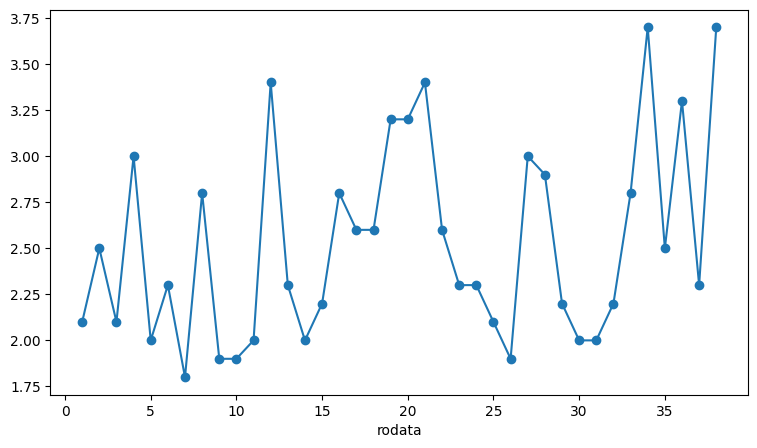

In [19]:
media_por_rodada = df_free.groupby("rodata")["totalGols"].mean()
media_por_rodada.plot(kind="line", marker="o", figsize=(9, 5))

Calculando a média de gols por rodada em todo o dataset pra ver se existe alguma relação


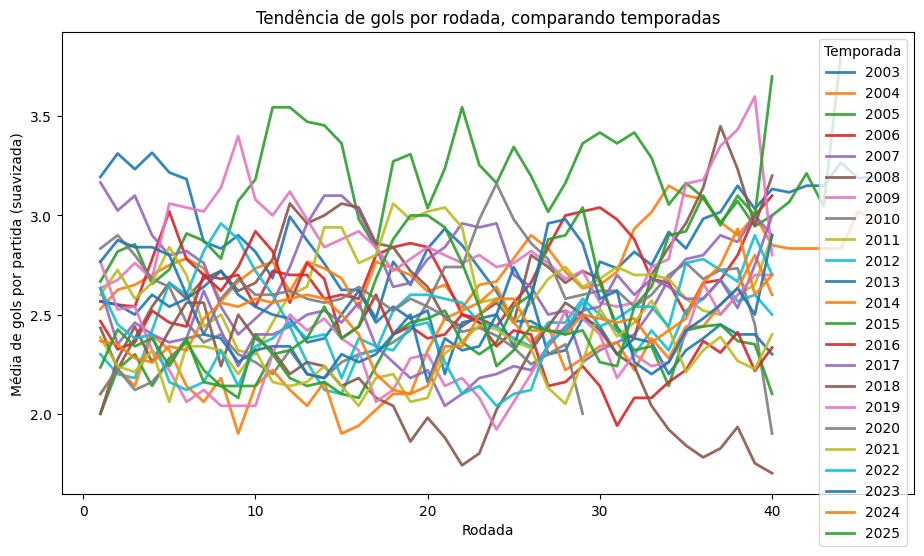

In [27]:
df["data"] = pd.to_datetime(df["data"])
df["temporada"] = df["data"].dt.year
df["totalGols"] = df["mandante_Placar"] + df["visitante_Placar"]

media = df.groupby(["temporada", "rodata"])["totalGols"].mean()
media = media.unstack(level="temporada")
suavizado = media.rolling(window=5, min_periods=1, center=True).mean()

plt.figure(figsize=(11, 6))
for temporada in suavizado.columns:
    plt.plot(suavizado.index, suavizado[temporada], linewidth=2, alpha=0.9, label=str(temporada))

plt.xlabel("Rodada")
plt.ylabel("Média de gols por partida (suavizada)")
plt.title("Tendência de gols por rodada, comparando temporadas")
plt.legend(title="Temporada")
plt.show()

Distribuição por partidas: qual a média de gols do campeonato? !Média de 2.52 gols por jogo em 2025!

In [ ]:
soma_mandante = df_free['mandante_Placar'].sum()
soma_visitante = df_free['visitante_Placar'].sum()
media_gols = (soma_mandante + soma_visitante) / len(df_free)
media_gols


np.float64(2.5236842105263158)

Como a média de gols variou ao longo do tempo? Pegando o dataset inteiro(méedia total de gols em todo o tempo do dataset)

In [ ]:
totalGols = (df['mandante_Placar'] + df['visitante_Placar']).sum()
totalGols
df['mediaGols'] = df['mandante_Placar'] + df['visitante_Placar']
df['mediaGols'].mean()


,mediaGols
ano,
2003,2.884058
2004,2.778986
2005,3.140693
2006,2.710526
2007,2.755263
2008,2.723684
2009,2.878947
2010,2.573684
2011,2.676316


Queremos testar se quando o jogo é interestadual tem mais ou menos gols que a média. **Constatação: Em jogos interestaduais sai menos gols, provavelmente porque os jogos são mais físicos(mais brigados)!**

In [ ]:
df['interestadual'] = df['mandante_Estado'] == df['visitante_Estado']
mediaArrInterEst = df.groupby('interestadual')['mediaGols'].mean()
mediaArrInterEst

,mediaGols
interestadual,
False,2.577970
True,2.421107


### 3.5 Relações entre formações táticas

Queremos testar a relação entre as formações e as taxas de vitórias no brasileirão de 2025 - DESCOBRIMOS AS FORMAÇÕES MAIS VENCEDORAS ENTRE OS MANDANTES, MAS NÃO SABEMOS QUANTAS VEZES USARAM ESSA FORMAÇÃO. **Constatação: observamos que a maioria são mais ofensivas!**

/tmp/ipykernel_3043/108353907.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_free['vitoria_mandante'] = df_free['vencedor'] == df_free['mandante']


<Axes: xlabel='vitoria_mandante', ylabel='formacao_mandante'>

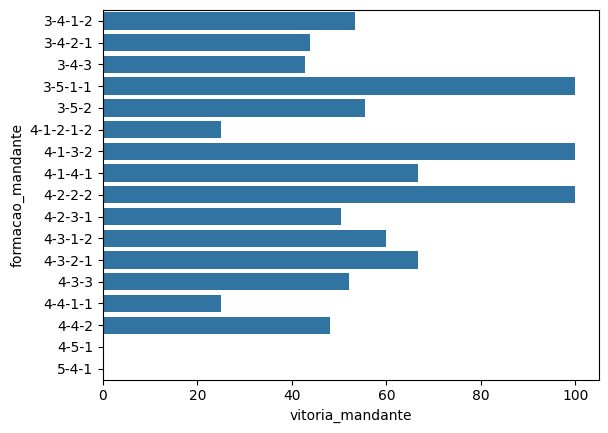

In [ ]:
df_free['vitoria_mandante'] = df_free['vencedor'] == df_free['mandante']

#calcula a taxa de aproveitamento (%) por formação
taxaAproveitamento = (df_free.groupby('formacao_mandante')['vitoria_mandante'].mean() * 100)

sns.barplot(data=taxaAproveitamento.reset_index(), x='vitoria_mandante', y='formacao_mandante')

Queremos testar a relação entre as formações e as taxas de vitórias no brasileirão de 2025 - DESCOBRIMOS AS FORMAÇÕES MAIS VENCEDORAS ENTRE OS VISITANTES, MAS NÃO SABEMOS QUANTAS VEZES USARAM ESSA FORMAÇÃO. **Constatação: observamos que a maioria são mais conservadoras!**

/tmp/ipykernel_3043/607426231.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_free['vitoria_visitante'] = df_free['vencedor'] == df_free['visitante']


<Axes: xlabel='vitoria_visitante', ylabel='formacao_visitante'>

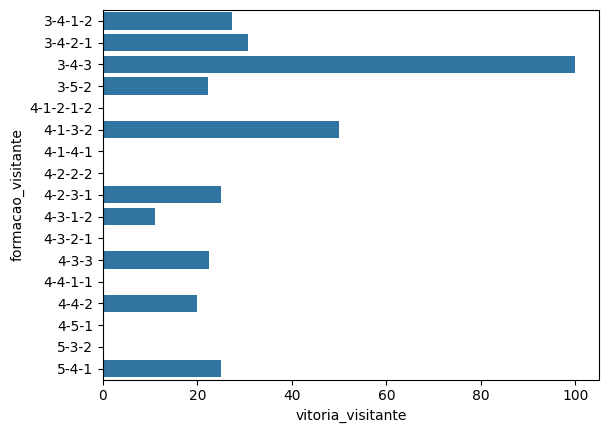

In [ ]:
df_free['vitoria_visitante'] = df_free['vencedor'] == df_free['visitante']

#calcula a taxa de aproveitamento (%) por formação
taxaAproveitamento = (df_free.groupby('formacao_visitante')['vitoria_visitante'].mean() * 100)

sns.barplot(data=taxaAproveitamento.reset_index(), x='vitoria_visitante', y='formacao_visitante')

### 3.6 Relações de mando de campo

Buscando entender se o Rio tem jogos a mais que SP

In [ ]:
df_rio = df.loc[df['mandante_Estado'] =='RJ']
df_rio

,ID,rodata,data,hora,mandante,visitante,formacao_mandante,formacao_visitante,tecnico_mandante,tecnico_visitante,vencedor,arena,mandante_Placar,visitante_Placar,mandante_Estado,visitante_Estado,arrecadacao
2,3,1,30/03/2003,16:00,Flamengo,Coritiba,NaN,NaN,NaN,NaN,-,Maracanã,1,1,RJ,PR,NaN
12,13,2,05/04/2003,16:00,Fluminense,Fortaleza,NaN,NaN,NaN,NaN,-,Maracanã,1,1,RJ,CE,NaN
23,24,2,06/04/2003,18:00,Vasco,Goias,NaN,NaN,NaN,NaN,Vasco,São Januário,6,4,RJ,GO,NaN
36,48,3,13/04/2003,18:00,Flamengo,Fluminense,NaN,NaN,NaN,NaN,Flamengo,Maracanã,4,1,RJ,RJ,NaN
43,32,4,16/04/2003,21:40,Vasco,Corinthians,NaN,NaN,NaN,NaN,-,São Januário,2,2,RJ,SP,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9139,9151,36,28/11/2025,19:30,Vasco,Internacional,4-2-3-1,4-3-1-2,F. Diniz,R. Díaz,Vasco,"Estádio São Januário, Rio de Janeiro",5,1,RJ,RS,1313832.0
9145,9118,37,02/12/2025,19:01,Vasco,Mirassol,4-2-3-1,4-2-3-1,F. Diniz,R. Guanaes,Mirassol,"Estádio São Januário, Rio de Janeiro",0,2,RJ,SP,1300947.0
9153,9124,37,03/12/2025,21:30,Flamengo,Ceara,4-2-3-1,4-2-3-1,F. Luís,M. Mozart,Flamengo,"Maracanã, Rio de Janeiro",1,0,RJ,CE,4950770.0
9157,9157,38,07/12/2025,16:04,Fluminense,Bahia,4-2-3-1,4-3-3,L. Luis Zubeldia,R. Ceni,Fluminense,"Maracanã, Rio de Janeiro",2,0,RJ,BA,1927662.5


In [ ]:
df_sp = df.loc[df['mandante_Estado'] == 'SP']
df_sp

,ID,rodata,data,hora,mandante,visitante,formacao_mandante,formacao_visitante,tecnico_mandante,tecnico_visitante,vencedor,arena,mandante_Placar,visitante_Placar,mandante_Estado,visitante_Estado,arrecadacao
0,1,1,29/03/2003,16:00,Guarani,Vasco,NaN,NaN,NaN,NaN,Guarani,Brinco de Ouro,4,2,SP,RJ,NaN
10,11,1,30/03/2003,18:00,Santos,Parana,NaN,NaN,NaN,NaN,-,Vila Belmiro,2,2,SP,PR,NaN
11,12,1,30/03/2003,18:00,Corinthians,Atletico-MG,NaN,NaN,NaN,NaN,Atletico-MG,Pacaembu,0,3,SP,MG,NaN
19,20,2,06/04/2003,16:00,Ponte Preta,Juventude,NaN,NaN,NaN,NaN,Ponte Preta,Moisés Lucarelli,1,0,SP,RS,NaN
21,22,2,06/04/2003,16:00,Sao Caetano,Criciuma,NaN,NaN,NaN,NaN,Sao Caetano,Anacleto Campanella,3,2,SP,SC,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9147,9134,34,03/12/2025,19:00,Bragantino,Vitoria,4-2-3-1,3-4-2-1,V. Mancini,J. Ventura,Bragantino,"Estádio Municipal Cicero De Souza Marques, Bra...",4,0,SP,BA,62435.00
9151,9122,37,03/12/2025,20:00,Sao Paulo,Internacional,3-4-1-2,4-3-1-2,H. Crespo,R. Díaz,Sao Paulo,"Estádio Urbano Caldeira, Santos",3,0,SP,RS,392052.50
9155,9156,38,06/12/2025,18:32,Mirassol,Flamengo,4-4-2,4-2-3-1,R. Guanaes,F. Luís,-,"Campos Maia, Mirassol",3,3,SP,RJ,1258100.00
9159,9159,38,07/12/2025,16:04,Corinthians,Juventude,3-4-3,4-2-3-1,D. Junior,M. Barbieri,-,"Neo Química Arena, São Paulo",1,1,SP,RS,1888899.00


Quantidade de empates na última temporada

In [ ]:
df_e = df_free[df['vencedor'] == '-']
df_e

/tmp/ipykernel_1033/1349944607.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_e = df_free[df['vencedor'] == '-']


,ID,rodata,data,hora,mandante,visitante,formacao_mandante,formacao_visitante,tecnico_mandante,tecnico_visitante,vencedor,arena,mandante_Placar,visitante_Placar,mandante_Estado,visitante_Estado,arrecadacao
8789,8789,1,29/03/2025,18:32,Sao Paulo,Sport,3-4-1-2,4-3-1-2,H. Crespo,C. de Lucena,-,"MorumBIS, São Paulo",0,0,SP,PE,2144747.0
8790,8791,1,29/03/2025,21:00,Flamengo,Internacional,4-4-2,4-2-3-1,F. Luís,R. Díaz,-,"Maracanã, Rio de Janeiro",1,1,RJ,RS,3150315.0
8791,8792,1,30/03/2025,16:01,Palmeiras,Botafogo-RJ,4-2-3-1,4-3-3,A. Ferreira,Renato Manuel Alves Paiva,-,"Allianz Parque, São Paulo",0,0,SP,RJ,2802427.7
8793,8794,1,30/03/2025,20:01,Bahia,Corinthians,4-2-3-1,4-3-3,R. Ceni,D. Junior,-,"Arena Fonte Nova, Salvador",1,1,BA,SP,1752529.0
8794,8795,1,31/03/2025,20:01,Bragantino,Ceara,4-2-3-1,4-2-3-1,V. Mancini,M. Mozart,-,"Nabizão, Bragança Paulista",2,2,SP,CE,61875.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9142,9154,36,29/11/2025,21:01,Ceara,Cruzeiro,4-2-3-1,4-2-3-1,M. Mozart,T. Tite,-,"Arena Castelão, Fortaleza",1,1,CE,MG,385906.0
9144,9155,36,30/11/2025,16:00,Corinthians,Botafogo-RJ,4-1-2-1-2,4-2-3-1,Dorival Silvestre Junior,Davide Ancelotti,-,"Neo Química Arena, São Paulo",2,2,SP,RJ,2694558.5
9154,9125,37,04/12/2025,19:32,Cruzeiro,Botafogo-RJ,4-2-3-1,4-2-3-1,Jose Leonardo Nunes Alves Sousa Jardim,Davide Ancelotti,-,"Mineirão, Belo Horizonte",2,2,MG,RJ,1038832.5
9155,9156,38,06/12/2025,18:32,Mirassol,Flamengo,4-4-2,4-2-3-1,R. Guanaes,F. Luís,-,"Campos Maia, Mirassol",3,3,SP,RJ,1258100.0


Mando de campo: times vencem mais jogando em casa? **Constatação: sim, ~50% de vitórias e ~24% de derrotas**

Distribuição geral de resultados:
resultado
Vitória Mandante     49.6
Empate               26.4
Vitória Visitante    23.9
Name: proportion, dtype: float64

Aproveitamento em casa x fora, por time (%):
                 aproveitamento_casa  aproveitamento_fora  diferenca
Barueri                         64.9                 21.1       43.8
Paysandu                        60.2                 16.4       43.8
Ipatinga                        52.6                  8.8       43.8
Guarani                         57.4                 17.9       39.5
Portuguesa                      55.6                 21.1       34.5
Athletico-PR                    64.4                 30.0       34.4
Joinville                       43.9                 10.5       33.4
Mirassol                        75.4                 42.1       33.3
Nautico                         50.9                 19.3       31.6
Criciuma                        52.1                 21.0       31.1
Gremio                          65.5    

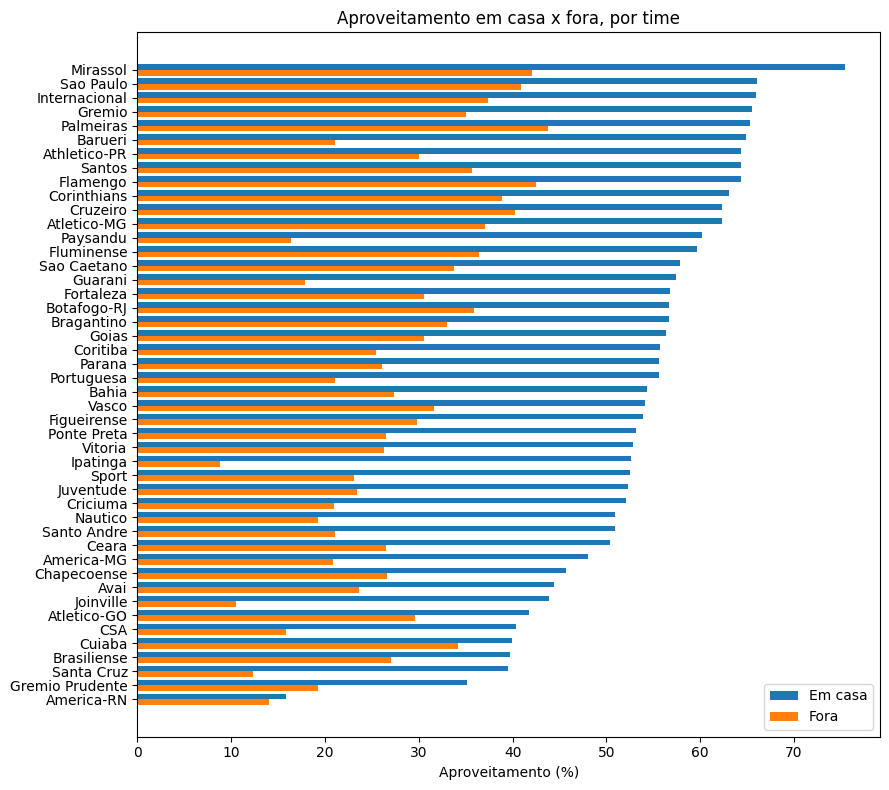

In [33]:
# 1. Cria a coluna de resultado usando a coluna "vencedor" que já existe
#    vencedor == mandante  -> Vitória Mandante
#    vencedor == visitante -> Vitória Visitante
#    vencedor == "-"       -> Empate

def resultado(row):
    if row["vencedor"] == row["mandante"]:
        return "Vitória Mandante"
    elif row["vencedor"] == row["visitante"]:
        return "Vitória Visitante"
    else:
        return "Empate"

df["resultado"] = df.apply(resultado, axis=1)

# 2. Visão geral: qual % de jogos termina em cada resultado?
percentuais = df["resultado"].value_counts(normalize=True).mul(100).round(1)
print("Distribuição geral de resultados:")
print(percentuais)
print()

# 3. Visão por time: aproveitamento como mandante x como visitante
#    (vitória = 3 pts, empate = 1 pt, derrota = 0 pt)

def pontos_mandante(row):
    if row["vencedor"] == row["mandante"]:
        return 3
    elif row["vencedor"] == "-":
        return 1
    return 0

def pontos_visitante(row):
    if row["vencedor"] == row["visitante"]:
        return 3
    elif row["vencedor"] == "-":
        return 1
    return 0

df["pontos_mandante"] = df.apply(pontos_mandante, axis=1)
df["pontos_visitante"] = df.apply(pontos_visitante, axis=1)

aproveitamento_casa = (df.groupby("mandante")["pontos_mandante"].mean() / 3 * 100).round(1)
aproveitamento_fora = (df.groupby("visitante")["pontos_visitante"].mean() / 3 * 100).round(1)

comparacao = pd.DataFrame({
    "aproveitamento_casa": aproveitamento_casa,
    "aproveitamento_fora": aproveitamento_fora,
})
comparacao["diferenca"] = comparacao["aproveitamento_casa"] - comparacao["aproveitamento_fora"]
comparacao = comparacao.sort_values("diferenca", ascending=False)

print("Aproveitamento em casa x fora, por time (%):")
print(comparacao)

# 4. Gráfico de barras comparando casa x fora, por time
comparacao_plot = comparacao.sort_values("aproveitamento_casa", ascending=True)

fig, ax = plt.subplots(figsize=(9, 8))
y = range(len(comparacao_plot))
ax.barh(y, comparacao_plot["aproveitamento_casa"], height=0.4, label="Em casa", color="#1f77b4", align="edge")
ax.barh([i - 0.4 for i in y], comparacao_plot["aproveitamento_fora"], height=0.4, label="Fora", color="#ff7f0e", align="edge")
ax.set_yticks(y)
ax.set_yticklabels(comparacao_plot.index)
ax.set_xlabel("Aproveitamento (%)")
ax.set_title("Aproveitamento em casa x fora, por time")
ax.legend()
plt.tight_layout()
plt.show()

Mando de campo: Qual a diferença de aproveitamento mandante x visitante?

In [ ]:
# 1. Contar o número de vitórias do mandante
vitorias_mandante = (df_free['mandante'] == df_free['vencedor']).sum()

# 2. Calcular o aproveitamento em porcentagem
total_jogos = len(df_free)
aproveitamento = (vitorias_mandante / total_jogos) * 100

print(f"Vitórias em casa: {vitorias_mandante} de {total_jogos} jogos")
print(f"Aproveitamento dos mandantes: {aproveitamento:.2f}%")

Vitórias em casa: 191 de 380 jogos
Aproveitamento dos mandantes: 50.26%


/tmp/ipykernel_3043/1086154847.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_free['resultado_mandante'] = (


<Axes: xlabel='resultado_mandante', ylabel='count'>

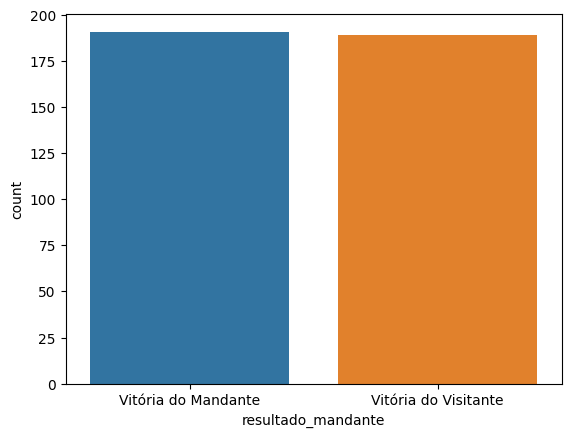

In [ ]:
#Gráfico de barras do de cima
df_free['resultado_mandante'] = (
    df_free['mandante'] == df_free['vencedor']
).map({True: 'Vitória do Mandante', False: 'Vitória do Visitante'})

sns.countplot(data=df_free, x='resultado_mandante', hue='resultado_mandante', legend=False)